# 04 - Clustering Analysis

This notebook applies clustering algorithms to Old School RuneScape player profiles.

The objective is to identify hidden player groups based on their skill progression and aggregated profile metrics.

Since no predefined labels exist, clustering is an appropriate unsupervised learning method.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## 2. Load the cleaned dataset

The cleaned dataset created in the previous notebook is loaded.

This dataset already contains:

- selected skill level features,
- engineered profile metrics,
- cleaned numeric values.

In [3]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
IMAGES_DIR = PROJECT_ROOT / "images"

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

input_path = PROCESSED_DATA_DIR / "osrs_hiscores_cleaned.csv"

input_path

WindowsPath('C:/Projects/osrs-player-segmentation/data/processed/osrs_hiscores_cleaned.csv')

In [4]:
df = pd.read_csv(input_path)

df.head()

,player,overall,attack,defence,strength,hitpoints,ranged,prayer,magic,cooking,...,construction,sailing,combat_score,gathering_score,production_score,support_score,average_skill_level,max_skill_level,min_skill_level,skill_level_std
0,Obbyy,2376,99,99,99,99,99,99,99,99,...,99,99,99.000000,99.0,99.00,99.0,99.000000,99,99,0.000000
1,Obby Cape,2376,99,99,99,99,99,99,99,99,...,99,99,99.000000,99.0,99.00,99.0,99.000000,99,99,0.000000
2,Obby Apples,2278,99,99,99,99,99,99,99,99,...,99,1,99.000000,79.4,99.00,99.0,94.916667,99,1,20.004166
3,Obby Kenobi,1752,1,1,99,90,65,31,60,99,...,75,99,49.571429,91.4,82.25,72.5,73.000000,99,1,27.700259
4,obbE x,2376,99,99,99,99,99,99,99,99,...,99,99,99.000000,99.0,99.00,99.0,99.000000,99,99,0.000000


In [5]:
df.shape

(808, 34)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 808 entries, 0 to 807
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player               808 non-null    object 
 1   overall              808 non-null    int64  
 2   attack               808 non-null    int64  
 3   defence              808 non-null    int64  
 4   strength             808 non-null    int64  
 5   hitpoints            808 non-null    int64  
 6   ranged               808 non-null    int64  
 7   prayer               808 non-null    int64  
 8   magic                808 non-null    int64  
 9   cooking              808 non-null    int64  
 10  woodcutting          808 non-null    int64  
 11  fletching            808 non-null    int64  
 12  fishing              808 non-null    int64  
 13  firemaking           808 non-null    int64  
 14  crafting             808 non-null    int64  
 15  smithing             808 non-null    int

## 3. Create the feature matrix

Clustering algorithms require a numeric matrix.

In this matrix:

- each row = one OSRS player
- each column = one numeric feature

The `player` column is only an identifier and is excluded from model training.

In [7]:
feature_columns = [column for column in df.columns if column != "player"]

X = df[feature_columns].copy()

X.head()

,overall,attack,defence,strength,hitpoints,ranged,prayer,magic,cooking,woodcutting,...,construction,sailing,combat_score,gathering_score,production_score,support_score,average_skill_level,max_skill_level,min_skill_level,skill_level_std
0,2376,99,99,99,99,99,99,99,99,99,...,99,99,99.000000,99.0,99.00,99.0,99.000000,99,99,0.000000
1,2376,99,99,99,99,99,99,99,99,99,...,99,99,99.000000,99.0,99.00,99.0,99.000000,99,99,0.000000
2,2278,99,99,99,99,99,99,99,99,99,...,99,1,99.000000,79.4,99.00,99.0,94.916667,99,1,20.004166
3,1752,1,1,99,90,65,31,60,99,99,...,75,99,49.571429,91.4,82.25,72.5,73.000000,99,1,27.700259
4,2376,99,99,99,99,99,99,99,99,99,...,99,99,99.000000,99.0,99.00,99.0,99.000000,99,99,0.000000


In [8]:
player_names = df["player"].values

player_names[:10]

array(['Obbyy', 'Obby Cape', 'Obby Apples', 'Obby Kenobi', 'obbE x',
       'Obby200', 'Obby z', 'obby', 'obbiz', 'Obby wang'], dtype=object)

## 4. Standardize the data

Distance-based clustering methods are sensitive to scale differences.

For example:

- total level
- average skill
- standard deviation

may have different numeric ranges.

Therefore StandardScaler is applied.

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 6.14504155e-01,  4.40211681e-01,  4.63407796e-01,
         3.57260115e-01,  3.61297906e-01,  3.75759403e-01,
         5.99304591e-01,  3.84684615e-01,  4.49984756e-01,
         5.06645928e-01,  5.29801575e-01,  5.37208190e-01,
         4.94779898e-01,  5.18563072e-01,  6.12545271e-01,
         5.30173046e-01,  5.69994777e-01,  6.37003970e-01,
         5.77362694e-01,  4.88321007e-01,  4.86118317e-01,
         6.81015495e-01,  6.32871674e-01,  6.16813156e-01,
         1.11907586e+00,  4.58372003e-01,  8.52707205e-01,
         5.98506413e-01,  5.68156219e-01,  6.40988395e-01,
         2.38644381e-01,  1.21874383e+00, -1.11720191e+00],
       [ 6.14504155e-01,  4.40211681e-01,  4.63407796e-01,
         3.57260115e-01,  3.61297906e-01,  3.75759403e-01,
         5.99304591e-01,  3.84684615e-01,  4.49984756e-01,
         5.06645928e-01,  5.29801575e-01,  5.37208190e-01,
         4.94779898e-01,  5.18563072e-01,  6.12545271e-01,
         5.30173046e-01,  5.69994777e-01,  6.37003970e-

## 5. PCA visualization before clustering

The dataset contains many dimensions.

Principal Component Analysis (PCA) reduces the feature space to two components while preserving as much variance as possible.

This helps visualize player profiles before clustering.

In [10]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame({
    "player": df["player"],
    "pca_1": X_pca[:, 0],
    "pca_2": X_pca[:, 1]
})

df_pca.head()

,player,pca_1,pca_2
0,Obbyy,3.242032,1.372130
1,Obby Cape,3.242032,1.372130
2,Obby Apples,2.327813,-1.708513
3,Obby Kenobi,-2.606730,1.208113
4,obbE x,3.242032,1.372130


In [11]:
explained_variance = pca.explained_variance_ratio_

print(f"PC1 explained variance: {explained_variance[0]:.2%}")
print(f"PC2 explained variance: {explained_variance[1]:.2%}")
print(f"Total explained variance: {explained_variance.sum():.2%}")

PC1 explained variance: 76.73%
PC2 explained variance: 6.81%
Total explained variance: 83.54%


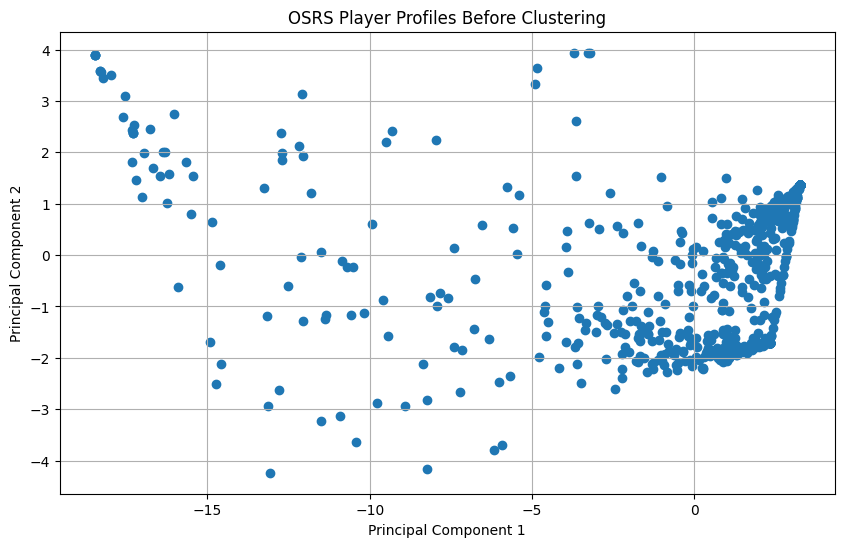

In [12]:
plt.figure(figsize=(10, 6))

plt.scatter(df_pca["pca_1"], df_pca["pca_2"])

plt.title("OSRS Player Profiles Before Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.show()

## 6. Determine the optimal number of clusters

The KMeans algorithm requires the number of clusters (`k`) in advance.

Two common evaluation approaches are used:

- Elbow Method
- Silhouette Score

### 6.1 Elbow Method

The inertia value measures within-cluster compactness.

Lower values are better, but diminishing returns indicate a suitable cluster number.

In [13]:
inertias = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

inertias

[26663.99999999994,
 10339.428975828492,
 7779.077972615502,
 6340.063617105724,
 5471.331777028676,
 4684.377703181068,
 4301.889136854673,
 4010.0643864211597,
 3762.5519241648053,
 3478.191680221892]

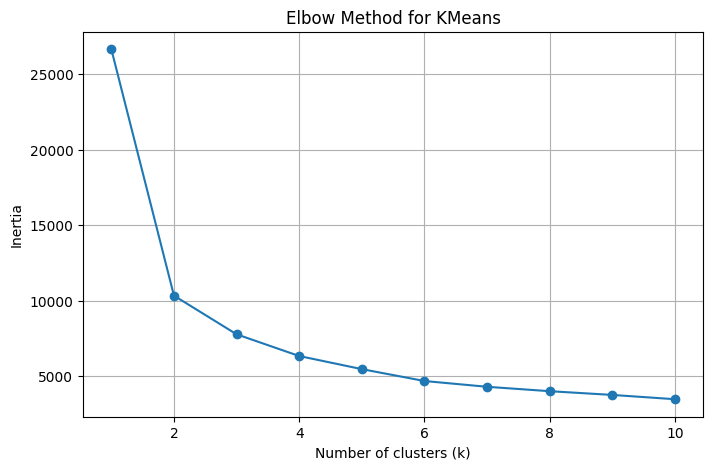

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, inertias, marker="o")

plt.title("Elbow Method for KMeans")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)

plt.show()

### 6.2 Silhouette Score

The silhouette score evaluates how well each player fits into its assigned cluster compared to neighboring clusters.

Higher values indicate better cluster separation.

In [15]:
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

silhouette_scores

[0.7259854677450219,
 0.5079976122713941,
 0.46939487841501737,
 0.46539883962575446,
 0.48514001364364395,
 0.48121277907016347,
 0.4831928803658946,
 0.4604168386333343,
 0.4605711445753339]

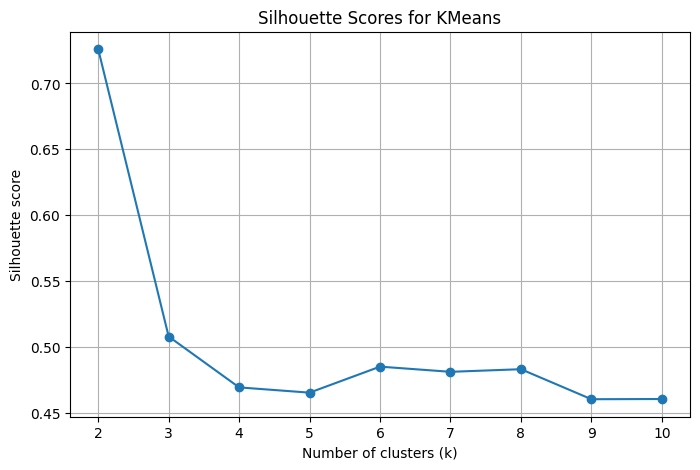

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, silhouette_scores, marker="o")

plt.title("Silhouette Scores for KMeans")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.grid(True)

plt.show()

## 7. Final KMeans clustering

Based on the evaluation metrics, a final cluster number is selected.

This value may be adjusted later depending on interpretability.

In [17]:
selected_k = 3

In [18]:
kmeans = KMeans(
    n_clusters=selected_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df_clustered = df.copy()
df_clustered["kmeans_cluster"] = kmeans_labels

df_clustered.head()

,player,overall,attack,defence,strength,hitpoints,ranged,prayer,magic,cooking,...,sailing,combat_score,gathering_score,production_score,support_score,average_skill_level,max_skill_level,min_skill_level,skill_level_std,kmeans_cluster
0,Obbyy,2376,99,99,99,99,99,99,99,99,...,99,99.000000,99.0,99.00,99.0,99.000000,99,99,0.000000,1
1,Obby Cape,2376,99,99,99,99,99,99,99,99,...,99,99.000000,99.0,99.00,99.0,99.000000,99,99,0.000000,1
2,Obby Apples,2278,99,99,99,99,99,99,99,99,...,1,99.000000,79.4,99.00,99.0,94.916667,99,1,20.004166,1
3,Obby Kenobi,1752,1,1,99,90,65,31,60,99,...,99,49.571429,91.4,82.25,72.5,73.000000,99,1,27.700259,0
4,obbE x,2376,99,99,99,99,99,99,99,99,...,99,99.000000,99.0,99.00,99.0,99.000000,99,99,0.000000,1


In [19]:
df_clustered["kmeans_cluster"].value_counts().sort_index()

kmeans_cluster
0    156
1    582
2     70
Name: count, dtype: int64

## 8. Visualize KMeans clusters in PCA space

Each point represents one player.

Color indicates the assigned cluster.

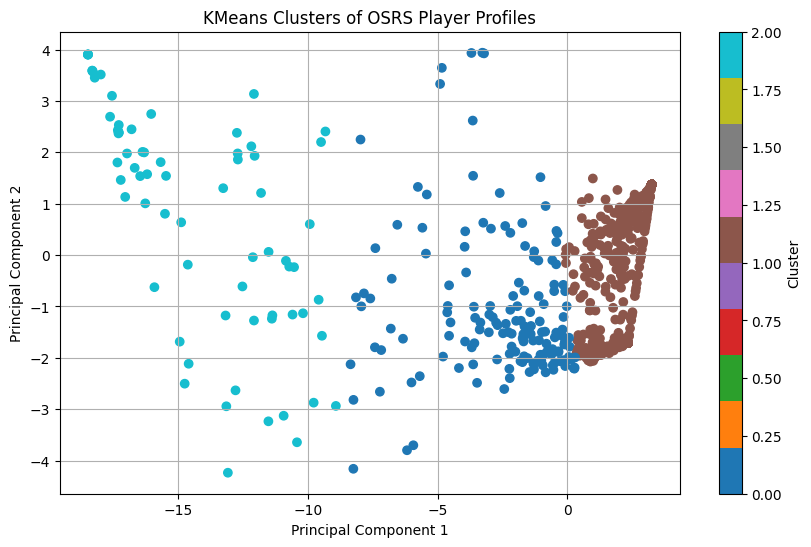

In [20]:
df_pca["kmeans_cluster"] = kmeans_labels

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df_pca["pca_1"],
    df_pca["pca_2"],
    c=df_pca["kmeans_cluster"],
    cmap="tab10"
)

plt.title("KMeans Clusters of OSRS Player Profiles")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.colorbar(scatter, label="Cluster")

plt.show()

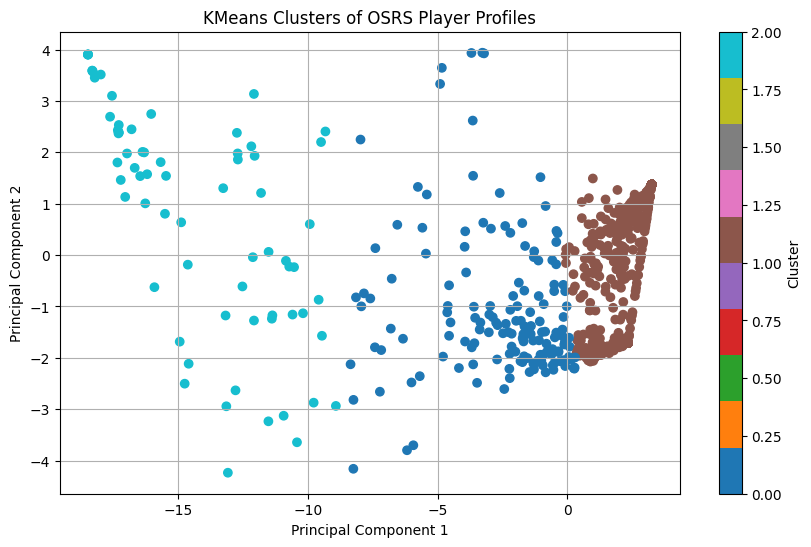

WindowsPath('C:/Projects/osrs-player-segmentation/images/kmeans_clusters_pca.png')

In [21]:
kmeans_plot_path = IMAGES_DIR / "kmeans_clusters_pca.png"

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df_pca["pca_1"],
    df_pca["pca_2"],
    c=df_pca["kmeans_cluster"],
    cmap="tab10"
)

plt.title("KMeans Clusters of OSRS Player Profiles")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.colorbar(scatter, label="Cluster")

plt.savefig(kmeans_plot_path, dpi=300, bbox_inches="tight")
plt.show()

kmeans_plot_path

## 9. Cluster profile interpretation

To understand the discovered player groups, average feature values are calculated per cluster.

In [22]:
cluster_profile = df_clustered.groupby("kmeans_cluster")[feature_columns].mean()

cluster_profile

,overall,attack,defence,strength,hitpoints,ranged,prayer,magic,cooking,woodcutting,...,construction,sailing,combat_score,gathering_score,production_score,support_score,average_skill_level,max_skill_level,min_skill_level,skill_level_std
kmeans_cluster,,,,,,,,,,,,,,,,,,,,,
0,1747.429487,74.967949,71.564103,83.480769,84.500000,83.666667,69.089744,81.852564,80.737179,76.070513,...,70.141026,14.211538,78.445971,62.110256,72.951122,72.838141,72.276442,96.403846,8.782051,21.888639
1,2284.912371,98.152921,97.408935,98.790378,98.740550,98.647766,94.951890,98.596220,97.836770,96.869416,...,94.501718,65.113402,97.898380,89.676976,95.763746,96.282216,95.204682,98.993127,62.692440,7.887833
2,343.928571,22.985714,21.414286,32.285714,28.928571,24.400000,16.000000,25.742857,24.285714,20.414286,...,16.485714,1.471429,24.536735,15.737143,17.096429,14.060714,18.477381,72.400000,1.057143,23.234655


In [23]:
profile_columns = [
    "overall",
    "combat_score",
    "gathering_score",
    "production_score",
    "support_score",
    "average_skill_level",
    "skill_level_std"
]

cluster_profile[profile_columns]

,overall,combat_score,gathering_score,production_score,support_score,average_skill_level,skill_level_std
kmeans_cluster,,,,,,,
0,1747.429487,78.445971,62.110256,72.951122,72.838141,72.276442,21.888639
1,2284.912371,97.898380,89.676976,95.763746,96.282216,95.204682,7.887833
2,343.928571,24.536735,15.737143,17.096429,14.060714,18.477381,23.234655


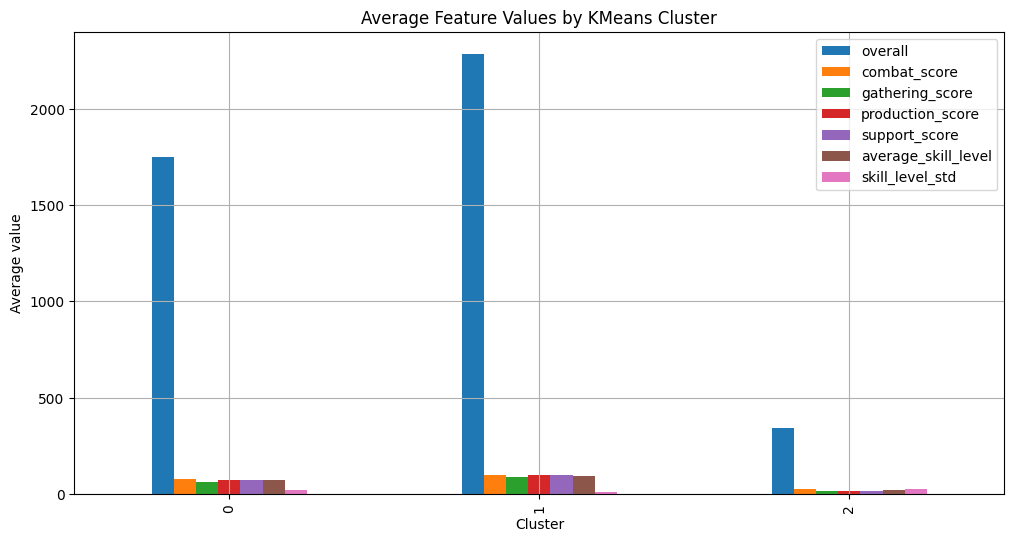

In [24]:
cluster_profile[profile_columns].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Feature Values by KMeans Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average value")
plt.grid(True)
plt.show()

In [25]:
for cluster_id in sorted(df_clustered["kmeans_cluster"].unique()):
    print(f"Cluster {cluster_id}")
    display(
        df_clustered[df_clustered["kmeans_cluster"] == cluster_id][
            ["player", "overall", "combat_score", "gathering_score", "production_score", "support_score", "average_skill_level"]
        ].head(10)
    )

Cluster 0


,player,overall,combat_score,gathering_score,production_score,support_score,average_skill_level
3,Obby Kenobi,1752,49.571429,91.4,82.250,72.50,73.000000
7,obby,1803,36.857143,79.4,99.000,89.00,75.125000
14,ObbMan,1964,94.857143,64.6,80.500,83.25,81.833333
15,Obby Skid,1707,80.857143,60.6,65.500,78.50,71.125000
18,obbset,1874,35.571429,72.8,97.125,83.50,71.833333
22,XPOQ,1383,78.857143,36.6,52.375,57.25,57.625000
34,xPottz,2004,95.714286,63.6,83.625,86.75,83.500000
35,xpotatoex,1966,95.857143,70.0,76.250,83.75,81.916667
37,i42,1849,77.142857,64.4,83.750,79.25,77.041667
38,i420u,1847,91.571429,58.8,74.125,79.75,76.958333


Cluster 1


,player,overall,combat_score,gathering_score,production_score,support_score,average_skill_level
0,Obbyy,2376,99.000000,99.0,99.000,99.00,99.000000
1,Obby Cape,2376,99.000000,99.0,99.000,99.00,99.000000
2,Obby Apples,2278,99.000000,79.4,99.000,99.00,94.916667
4,obbE x,2376,99.000000,99.0,99.000,99.00,99.000000
5,Obby200,2365,99.000000,96.8,99.000,99.00,98.541667
6,Obby z,2278,99.000000,79.4,99.000,99.00,94.916667
8,obbiz,2138,99.000000,69.8,89.750,94.50,89.083333
9,Obby wang,2376,99.000000,99.0,99.000,99.00,99.000000
10,obbenheimer,2071,96.571429,69.2,86.625,89.00,86.291667
11,Obbib,2276,96.000000,95.4,93.750,94.25,94.833333


Cluster 2


,player,overall,combat_score,gathering_score,production_score,support_score,average_skill_level
42,i42i,0,36.000000,13.6,31.125,1.00,23.875000
80,w1de,829,42.000000,25.6,35.750,30.25,34.541667
81,W1D0WG1rl,44,3.857143,1.0,1.000,1.00,1.833333
83,Tbztom,0,1.000000,31.6,1.000,1.00,7.375000
85,tbzsd,0,48.428571,1.0,1.000,14.00,17.000000
86,tbz12,0,10.857143,1.0,1.000,1.00,3.875000
124,82busyair,0,1.000000,1.0,9.125,1.00,3.708333
126,LLIGMA,1432,80.142857,11.2,29.625,48.00,43.583333
153,icd tea,1218,10.857143,10.2,42.375,45.00,26.916667
174,mgCiN,0,1.000000,21.0,34.625,50.25,24.583333


## 10. Compare with hierarchical clustering

A second clustering method is applied for comparison.

Hierarchical clustering groups players step-by-step instead of using centroids.

In [26]:
hierarchical = AgglomerativeClustering(n_clusters=selected_k)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

df_clustered["hierarchical_cluster"] = hierarchical_labels

df_clustered[["player", "kmeans_cluster", "hierarchical_cluster"]].head()

,player,kmeans_cluster,hierarchical_cluster
0,Obbyy,1,2
1,Obby Cape,1,2
2,Obby Apples,1,1
3,Obby Kenobi,0,1
4,obbE x,1,2


In [27]:
df_clustered["hierarchical_cluster"].value_counts().sort_index()

hierarchical_cluster
0    100
1    279
2    429
Name: count, dtype: int64

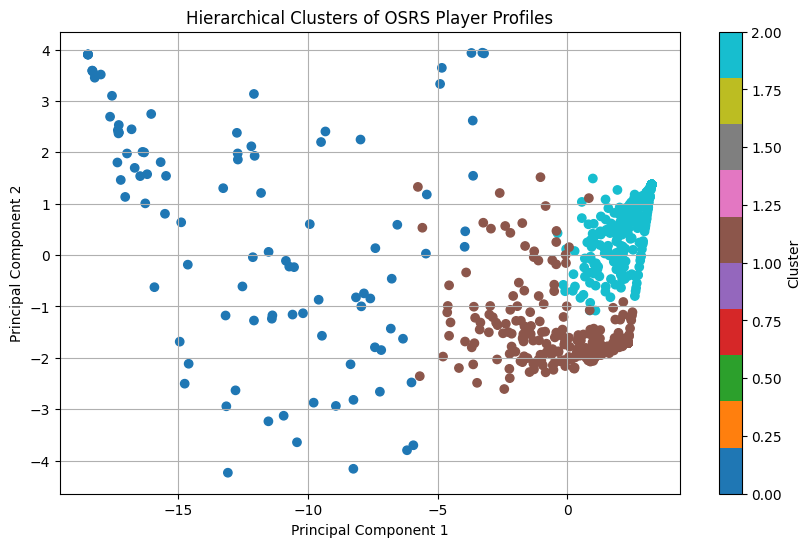

In [28]:
df_pca["hierarchical_cluster"] = hierarchical_labels

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df_pca["pca_1"],
    df_pca["pca_2"],
    c=df_pca["hierarchical_cluster"],
    cmap="tab10"
)

plt.title("Hierarchical Clusters of OSRS Player Profiles")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.colorbar(scatter, label="Cluster")

plt.show()

## 11. Compare with DBSCAN

DBSCAN is a density-based clustering algorithm.

It can detect:

- irregular cluster shapes
- noise points
- outliers

In [29]:
dbscan = DBSCAN(
    eps=2.5,
    min_samples=3
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df_clustered["dbscan_cluster"] = dbscan_labels

In [30]:
df_clustered["dbscan_cluster"].value_counts().sort_index()

dbscan_cluster
-1    102
 0    685
 1     10
 2      3
 3      4
 4      4
Name: count, dtype: int64

## 12. Save clustering results

The final dataset with cluster labels is saved for later reporting and GitHub presentation.

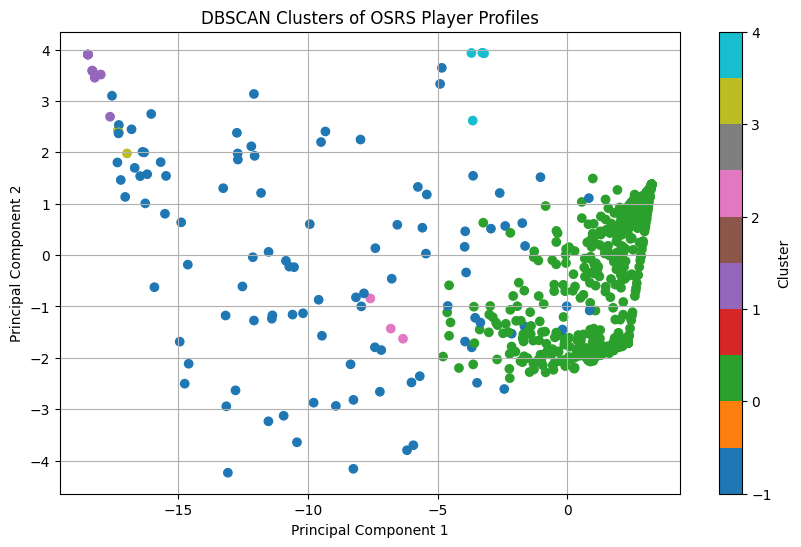

In [31]:
df_pca["dbscan_cluster"] = dbscan_labels

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df_pca["pca_1"],
    df_pca["pca_2"],
    c=df_pca["dbscan_cluster"],
    cmap="tab10"
)

plt.title("DBSCAN Clusters of OSRS Player Profiles")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.colorbar(scatter, label="Cluster")

plt.show()

In [32]:
clustered_output_path = PROCESSED_DATA_DIR / "osrs_hiscores_clustered.csv"

df_clustered.to_csv(clustered_output_path, index=False, encoding="utf-8")

clustered_output_path

WindowsPath('C:/Projects/osrs-player-segmentation/data/processed/osrs_hiscores_clustered.csv')

## Summary

In this notebook, clustering methods were applied to OSRS player profiles.

The analysis included:

- feature matrix creation,
- standard scaling,
- PCA visualization,
- KMeans clustering,
- Elbow Method,
- Silhouette Score,
- cluster interpretation,
- hierarchical clustering,
- DBSCAN clustering,
- saving clustered results.

The KMeans model was used as the main clustering method because it provides interpretable centroid-based player groups.

In [33]:
cluster_profile[profile_columns]

,overall,combat_score,gathering_score,production_score,support_score,average_skill_level,skill_level_std
kmeans_cluster,,,,,,,
0,1747.429487,78.445971,62.110256,72.951122,72.838141,72.276442,21.888639
1,2284.912371,97.898380,89.676976,95.763746,96.282216,95.204682,7.887833
2,343.928571,24.536735,15.737143,17.096429,14.060714,18.477381,23.234655


## Final Interpretation of KMeans Clusters

Based on the selected KMeans model (`k = 3`), three meaningful Old School RuneScape player archetypes were identified from the public Hiscores dataset.

### Cluster 0 – Mid to High-Level Main Accounts

This cluster represents experienced players with strong overall progression, but not yet near-maxed profiles.

Characteristics:

- high combat levels,
- solid skilling progression,
- balanced development across all categories,
- moderate skill variance.

Average values:

- Overall level: 1747
- Combat score: 78.45
- Gathering score: 62.11
- Production score: 72.95
- Support score: 72.84
- Average skill level: 72.28

These players likely represent regular long-term main accounts.

---

### Cluster 1 – Veteran / Advanced Main Accounts

This cluster contains the most progressed and most balanced player profiles.

Characteristics:

- near-max combat progression,
- very high skilling levels,
- strong development in all categories,
- low variance between skills.

Average values:

- Overall level: 2284
- Combat score: 97.90
- Gathering score: 89.68
- Production score: 95.76
- Support score: 96.28
- Average skill level: 95.20

These players likely represent veteran players, completionists or highly active long-term mains.

---

### Cluster 2 – Beginner / Casual Accounts

This cluster includes low-level players with limited progression.

Characteristics:

- low combat levels,
- low skilling levels,
- early-game or casual progression,
- higher variance caused by uneven skill development.

Average values:

- Overall level: 343
- Combat score: 24.54
- Gathering score: 15.74
- Production score: 17.10
- Support score: 14.06
- Average skill level: 18.48

These players likely represent new players, inactive accounts or casual users.

---

## Overall Conclusion

The clustering results show that unsupervised learning successfully identified natural player progression groups within OSRS public Hiscores data.

The three main player archetypes are:

1. Beginner / Casual Accounts  
2. Mid-Level Developing Main Accounts  
3. Veteran / Advanced Main Accounts

This demonstrates that public game statistics can be effectively used to detect meaningful behavioral and progression patterns using clustering techniques.